#**Designing Multi-Arm Bandit Algorithm For Parallel Design: Analyzing the Impact of Price Markdown Strategies on E-commerce**

<mark>**This is section of code is from Assignment 1 & Assignment 2**

In [304]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#**Synthetic Data** <br>
Platform: Shopper's Drug Mart <br>
Number of Participants: 10000<br>
Demographic info: Age, Gender, Location, Income <br>
User Purchase Behavior: Past Purchase History, Frequency of Visits, Frequency of Made Purchase, Types of Purchases <br>
Dependent Variables: Session Duration, Conversion Rate, Number of Items, Average Order Value (Add two more variables Average Item Value * Number of Items Purchased to compute the AOV)

Note: We generated the independent, demographic variables below. We then chose to generate the dependent variables such as Frequency of Visits,	Frequency of Made Purchase, Conversion Rate, and Session Duration within each experiment separately.

In [305]:
# Define constants
n_participants = 10000
frequent_threshold = 50  # Threshold for being a frequent user

# Generate Historical Visits
historical_visits = np.random.randint(0, 100, n_participants)

# Determine frequency in past based on threshold
frequency_in_past = np.where(historical_visits > frequent_threshold, 'frequent', 'not frequent')

# Generate synthetic dataset
participants_data = {
    "Participant ID": np.arange(1, n_participants + 1),
    "Age": np.random.randint(18, 71, n_participants),
    "Gender": np.random.choice(['Male', 'Female', 'Non-Binary'], n_participants),  # Expanded gender options
    "Location": np.random.choice(['Toronto', 'Montreal', 'Vancouver', 'Calgary', 'Edmonton',
                                  'Ottawa', 'Winnipeg', 'Quebec City', 'Hamilton', 'Kitchener',
                                  'London', 'Victoria', 'Halifax', 'Oshawa', 'Windsor',
                                  'Saskatoon', 'Regina', 'St. John\'s', 'Kelowna', 'Barrie'], n_participants),
    "Income": np.random.randint(0, 200001, n_participants),
    "Frequency in the Past": frequency_in_past,
    "Historical Visits": historical_visits,
    "Device Type": np.random.choice(["Mobile", "Desktop", "Tablet"], n_participants),
    "Preferred Payment Method": np.random.choice(["Credit Card", "PayPal", "Bank Transfers", "Buy Now Pay Later", "Digital Wallet", "Debit"], n_participants),
    "Membership Status": np.random.choice(["Basic", "Silver", "Gold", "Platinum"], n_participants),
    "Exposure to Social Media Promotion": np.random.choice(["Yes", "No"], n_participants)
}

# Create DataFrame
df = pd.DataFrame(participants_data)
df.head(15)

,Participant ID,Age,Gender,Location,Income,Frequency in the Past,Historical Visits,Device Type,Preferred Payment Method,Membership Status,Exposure to Social Media Promotion
0,1,64,Female,Victoria,124299,not frequent,10,Desktop,Bank Transfers,Basic,Yes
1,2,61,Female,Montreal,29708,frequent,62,Tablet,Buy Now Pay Later,Silver,Yes
2,3,66,Male,Victoria,98311,frequent,68,Tablet,Credit Card,Gold,Yes
3,4,32,Non-Binary,Kelowna,199538,frequent,55,Mobile,PayPal,Platinum,No
4,5,32,Female,Hamilton,174238,not frequent,6,Tablet,Digital Wallet,Gold,Yes
5,6,38,Female,Ottawa,140036,not frequent,50,Mobile,Digital Wallet,Basic,No
6,7,31,Non-Binary,Regina,160427,frequent,94,Tablet,Digital Wallet,Basic,Yes
7,8,28,Male,Montreal,17202,not frequent,38,Mobile,Buy Now Pay Later,Silver,Yes
8,9,28,Female,Winnipeg,48483,not frequent,41,Mobile,Bank Transfers,Gold,Yes
9,10,37,Female,Ottawa,17390,frequent,71,Mobile,Bank Transfers,Gold,No


#**1.1: Parallel Design**
​
**Power Analysis, Sample Size, & Associated Graph** </br>
>Effect Size: Medium (0.5)</br>
Power: 0.85 <br>
Total Sample Size: 292 </br>

In [306]:
from statsmodels.stats.power import TTestIndPower

# Power Analysis for Parallel Design Scenario

# Medium effect size
effect_size = 0.5
# Significance level
alpha = 0.05
# Power value
power = 0.85
# parallel design
number_groups = 4

# Creating a power analysis object
analysis = TTestIndPower()

# Calculating the required sample size per group
result = analysis.solve_power(effect_size=effect_size, alpha=alpha, power=power)

# Rounding to get integer sample size
required_sample_size_per_group = round(result)

# Total sample size required for the experiment
total_sample_size = required_sample_size_per_group * number_groups

# Output the result
print(f'Required sample size per group: {required_sample_size_per_group}')
print(f'Total sample size for all groups: {total_sample_size}')

Required sample size per group: 73
Total sample size for all groups: 292


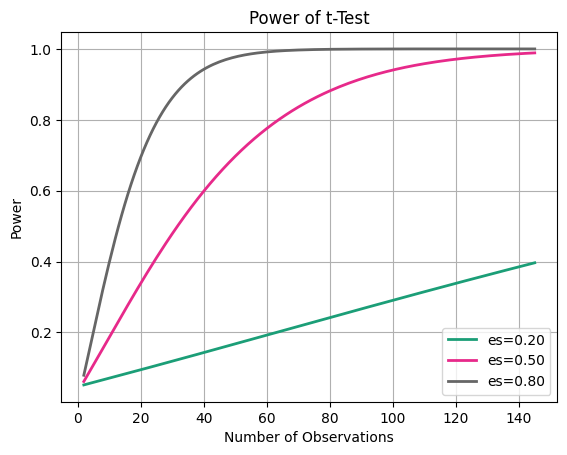

In [307]:
from numpy import array
from matplotlib import pyplot

# Effect sizes: small (0.2), medium (0.5), large (0.8)
effect_sizes = array([0.2, 0.5, 0.8])

# Sample sizes: range from 2 to 146
sample_sizes = array(range(2, 146))

# Create a power analysis object for t-tests
analysis = TTestIndPower()

# Plot power curves
analysis.plot_power(dep_var='nobs', nobs=sample_sizes, effect_size=effect_sizes, alpha=0.05, title='Power of t-Test')

# Formatting the plot
pyplot.grid()
pyplot.ylabel('Power')
pyplot.show()

**BLOCKING, TWO-WAY ANOVA, POST-HOC TUKEY'S HSD TEST & ASSUMPTION CHECKS FOR ANOVA** <br>

><mark>**Assignment 2 - Blocking for parallel analysis using Membership Status as blocking factor** <br>

> Platinum level customers might be more willing to purchase, regardless of the promotion. <br>
Confounding Effect: If a specific promotion is used more often in platinum level vs. another one in the gold, silver, basic levels, the promotion's effect on conversion may be overestimated. <br>

In [308]:
# Setting the seed for reproducibility: so that our analysis and conclusions remain consistent
np.random.seed(42)

# Define membership levels
membership_labels = ["Basic", "Silver", "Gold", "Platinum"]

# Assign random membership status to each participant
df["Membership_Status"] = np.random.choice(membership_labels, size=len(df), replace=True)

# Create a dictionary to store the participants by membership status
membership_samples = {}

# Loop through each membership level and randomly select 73 participants
for membership_level in membership_labels:
    selected = df[df["Membership_Status"] == membership_level].sample(n=73, random_state=42)
    membership_samples[membership_level] = selected

# Combine all selected participants into one DataFrame
selected_participants = pd.concat(membership_samples.values())

# Find remaining participants who were not selected
remaining_participants = df[~df["Participant ID"].isin(selected_participants["Participant ID"])]

# Randomly select 2 extra participants from the remaining ones
extra_participant = remaining_participants.sample(n=2, random_state=42)

# Count how many participants are in each membership status
membership_counts = selected_participants["Membership_Status"].value_counts()

# Print out the number of participants in each membership status & display the dataframe
print(membership_counts)
print("\n")

selected_features = ["Participant ID", 'Income', "Membership_Status"]
# Displaying the specific subset
selected_participants[selected_features].head(10)

Membership_Status
Basic       73
Silver      73
Gold        73
Platinum    73
Name: count, dtype: int64




,Participant ID,Income,Membership_Status
6178,6179,22534,Basic
724,725,94498,Basic
1772,1773,46688,Basic
9267,9268,77211,Basic
8189,8190,47479,Basic
5656,5657,32622,Basic
6092,6093,105299,Basic
4575,4576,37620,Basic
1003,1004,91789,Basic
1696,1697,57366,Basic


>**Randomization for Parallel Design After Blocking Done Above**

Now our parallel design has 4 variants/categorical variables as treatments. We added Group 3: Percentage Discount and Group 4: Loyalty Discount.

In [309]:
# Setting the seed for reproducibility
np.random.seed(42)

# Now we must randomly assign 73 participants to each of the 4 groups:
# Group 1: Buy One Get One Free
# Group 2: No Discount
# Group 3: Percentage Discount
# Group 4: Loyalty Discount

# Defining the group combinations based on above parallel design
parallel_conditions = [
    ('Buy One Get One Free'),  # Group 1
    ('No Discount'),  # Group 2
    ('Percentage Discount'), # Group 3
    ('Loyalty Discount')  # Group 4
]

# There will be 4 groups/variants
num_groups_p = len(parallel_conditions)
# Based on the power analysis, we will evenly split 73 individuals per group
group_size_p = len(selected_participants) // num_groups_p

# Initializing the list to store assigned treatment levels
treatment_assignments = []

# Randomly assign participants to groups by shuffling the IDs
np.random.shuffle(selected_participants['Participant ID'].values)

# Assigning participants evenly to parallel design groups using a loop
for i in range(len(selected_participants)):
    # Cycling through the 2 groups in the given order
    group_index = i % num_groups_p
    # Getting the corresponding treatment levels
    treatment = parallel_conditions[group_index]
    # Appending the assigned discount condition
    treatment_assignments.append(treatment)

# Adding the factor assignments to the DataFrame
selected_participants['DiscountType'] = treatment_assignments

# Now we will generate the dependent variables for this experiment
n_samples = len(selected_participants)

# Initializing activity data with zeros as placeholders
frequency_of_visits = np.zeros(n_samples)
frequency_of_made_purchase = np.zeros(n_samples)

# Define mean and standard deviation values for visit frequency based on treatment type
# Higher expected visits for promotional offer
visit_mean_treatment, visit_std_treatment = 30, 10
# Lower expected visits without discount
visit_mean_control, visit_std_control = 12, 5
# Higher visits for loyalty members
visit_mean_loyalty, visit_std_loyalty = 35, 8
# Standard deviation as a fraction of mean visits to account for variability
purchase_std_factor = 0.5

# Looping through each of the rows
for i in range(n_samples):
  # Holds the treatment type ('Buy One Get One Free' or 'No Discount') for the current participant
  treatments = treatment_assignments[i]

  if treatments == 'Buy One Get One Free':
    # Generate frequency of visits from normal distribution, with non-negative values
    frequency_of_visits[i] = max(0, int(np.random.normal(visit_mean_treatment, visit_std_treatment)))
  elif treatments == 'Percentage Discount':
    # Generate frequency of made purchase from normal distribution, with non-negative values greater than 5
    frequency_of_made_purchase[i] = max(5, int(np.random.normal(10, 3)))
    # Generate frequency of visits from normal distribution, with non-negative values greater than or equal to the # of visits
    frequency_of_visits[i] = max(frequency_of_made_purchase[i], int(np.random.normal(25, 7)))
  elif treatments == 'Loyalty Discount':
    # Generate frequency of visits from normal distribution, with non-negative values greater than or equal to 25 visits
    frequency_of_visits[i] = max(25, int(np.random.normal(visit_mean_loyalty, visit_std_loyalty)))
  else:
    # Generate frequency of visits from normal distribution, with non-negative values
    frequency_of_visits[i] = max(0, int(np.random.normal(visit_mean_control, visit_std_control)))

  # Generate purchase frequency based on visits, ensuring it does not exceed visits
  # Assuming 50% conversion rate on average
  purchase_mean = frequency_of_visits[i] * 0.5
  # Define variability in purchases
  purchase_std = purchase_mean * purchase_std_factor
  # Generate the number of purchases, ensuring it is within valid bounds (0 to total visits)
  frequency_of_made_purchase[i] = max(0, min(frequency_of_visits[i], int(np.random.normal(purchase_mean, purchase_std))))

# Calculating conversion rate: purchases made to visits but accounting for zero values
conversion_rate = np.divide(frequency_of_made_purchase, frequency_of_visits, where=frequency_of_visits > 0)
# Replacing any strange values with 0 (i.e. NaN, negative & positive infinity)
conversion_rate = np.nan_to_num(conversion_rate, nan=0, posinf=0, neginf=0)
conversion_rate = np.round(conversion_rate, 5)

# Rounding the values for the dependent variables
frequency_of_visits = np.round(frequency_of_visits, 2)
frequency_of_made_purchase = np.round(frequency_of_made_purchase, 2)

# Creating activity DataFrame
activity_data = pd.DataFrame({
    "Participant ID": selected_participants["Participant ID"],
    "Frequency of Visits": frequency_of_visits,
    "Frequency of Made Purchase": frequency_of_made_purchase,
    "Conversion_Rate": conversion_rate
})

# Merging the membership status and activity data together
df_parallel = selected_participants.merge(activity_data, on="Participant ID")

# Count the number of participants in each treatment group
treatment_counts = selected_participants['DiscountType'].value_counts()

# Print out the counts to make sure they are evenly distributed
print(treatment_counts)
print("\n")

# Selecting the subset features that should be displayed for parallel design
subset_features = [
    'Participant ID', 'Income', 'Membership_Status', 'DiscountType',
    'Frequency of Visits', 'Frequency of Made Purchase', 'Conversion_Rate'
]

# Show the demographic data for the selected participants
df_parallel[subset_features].head(10)

DiscountType
Buy One Get One Free    73
No Discount             73
Percentage Discount     73
Loyalty Discount        73
Name: count, dtype: int64




,Participant ID,Income,Membership_Status,DiscountType,Frequency of Visits,Frequency of Made Purchase,Conversion_Rate
0,7472,22534,Basic,Buy One Get One Free,22.0,4.0,0.18182
1,8259,94498,Basic,No Discount,15.0,12.0,0.80000
2,2692,46688,Basic,Percentage Discount,31.0,8.0,0.25806
3,7680,77211,Basic,Loyalty Discount,36.0,5.0,0.13889
4,4860,47479,Basic,Buy One Get One Free,22.0,15.0,0.68182
5,251,32622,Basic,No Discount,10.0,8.0,0.80000
6,7958,105299,Basic,Percentage Discount,44.0,23.0,0.52273
7,4392,37620,Basic,Loyalty Discount,25.0,12.0,0.48000
8,1697,91789,Basic,Buy One Get One Free,20.0,14.0,0.70000
9,8922,57366,Basic,No Discount,12.0,5.0,0.41667


>**TWO-WAY ANOVA & SUMMARY STATISTICS: After blocking using membership status level and then randomly assigning each participant into two groups we use two-way ANOVA to find the significance of the blocking factor based on the p-value**

In [310]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Making sure that the two variables (DscountType & Membership_Status) are both categorical variables
df_parallel["DiscountType"] = df_parallel["DiscountType"].astype("category")
df_parallel["Membership_Status"] = df_parallel["Membership_Status"].astype("category")

# Create model
formula = 'Conversion_Rate ~ DiscountType + Membership_Status + DiscountType:Membership_Status'
model = sm.formula.ols(formula, data=df_parallel).fit()

# Perform ANOVA and print table
aov_table = sm.stats.anova_lm(model)
print(aov_table)
print(model.summary())

                                   df     sum_sq   mean_sq         F    PR(>F)
DiscountType                      3.0   0.343976  0.114659  1.664722  0.174864
Membership_Status                 3.0   0.196482  0.065494  0.950906  0.416437
DiscountType:Membership_Status    9.0   0.385906  0.042878  0.622551  0.777570
Residual                        276.0  19.009643  0.068876       NaN       NaN
                            OLS Regression Results                            
Dep. Variable:        Conversion_Rate   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                 -0.005
Method:                 Least Squares   F-statistic:                    0.8967
Date:                Tue, 01 Apr 2025   Prob (F-statistic):              0.568
Time:                        03:10:01   Log-Likelihood:                -15.486
No. Observations:                 292   AIC:                             62.97
Df Residuals:                     276   BIC:        

# <mark> **The Section Below is for Assignment 3 Code**

# **1.2: Thompson Sampling - Rule Based**

Multi-Armed Bandit Setup (Thompson Sampling) - Experimental Design

Dataset: We have randomly selected a total of 8000 rows from the dataset for analysis, utilizing a multi-armed bandit approach to efficiently exploit resources while continuing to explore. include 4 Types: 'BOGOF', 'ND', 'PD', 'LD'. 2000 samples each treatment.

Experiment Overview:
The experiment uses Thompson Sampling to reallocate sample sizes across treatments based on conversion rate.


In [311]:
import numpy as np
import pandas as pd

# draw 4000 samples to simulate MAB online experimental data
mab_df = df.sample(n=8000, random_state=42).copy()

mab_df.head()

#define treatments
# 'Buy One Get One Free' => 'BOGOF'
# 'No Discount' => 'ND'
# 'Percentage Discount' => 'PD'
# 'Loyalty Discount' => 'LD'
treatments = ['BOGOF', 'ND', 'PD', 'LD']
mab_df['Treatment'] = np.tile(treatments, 2000)  # evenly allocate 1000 each

#assign conversion rate
#base conversion rate ranking(slightly favoring LD and BOGOF)
conversion_treatment = {
    'LD': (0.19, 0.30),
    'BOGOF': (0.18, 0.30),
    'PD': (0.19, 0.29),
    'ND': (0.18, 0.28)
}

# Assign conversion rate based on treatment
def assign_conversion_rate(treatment):
    low, high = conversion_treatment[treatment]
    return np.round(np.random.uniform(low, high), 4)

#apply the function to the dataset
mab_df['Conversion Rate'] = mab_df['Treatment'].apply(assign_conversion_rate)

#keep participant, treatment and conversion rate fields only
mab_df = mab_df[['Participant ID', 'Treatment', 'Conversion Rate']]

mab_df.head()

,Participant ID,Treatment,Conversion Rate
6252,6253,BOGOF,0.2415
4684,4685,ND,0.2031
1731,1732,PD,0.2077
4742,4743,LD,0.2143
4521,4522,BOGOF,0.2024


**Rewarding Rules & Stopping Rules:**

Initial Conditions (Iteration 1):
- Each treatment (variant) starts with exactly 25 samples.
- The average conversion rate is calculated for each treatment.
- The treatment with the highest average conversion rate is considered the winner.

Allocation and Rewarding Rules (from Iteration 2 onward):
- Each iteration has a total sample size of 100 participants.
- Allocation is based on the previous round's sample sizes.
- The winner is determined by the highest average conversion rate in the current round.
- Sample reallocation is done as follows:

1.  Winner gains 35% of total samples taken from the other 3 treatments.
2.  2nd place loses 5% of its previous sample size.
3. 3rd place loses 10%.
4. 4th place loses 15%.
5. All percentage changes are rounded to the nearest integer.

- After reallocating, the total number of samples must remain exactly 100.

Stopping Rule:
- The simulation stops when any treatment receives fewer than 5 samples.

In [312]:
import pandas as pd
import random

# Set random seed for reproducibility
random.seed(12)

# Shuffle your data for random sampling
mab_df = mab_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Define the 4 treatment names
treatments = ['BOGOF', 'ND', 'PD', 'LD']
num_variants = len(treatments)

# Start with 25 samples per treatment = 100 total
initial_allocation = [25, 25, 25, 25]
current_allocation = initial_allocation.copy()

# These lists will store data for each round to track performance over time
allocation_history = [current_allocation.copy()]
conversion_history = []

# Going through the dataset row by row
data_index = 0
iteration = 1
stop = False

print("=== Thompson Sampling with Custom Reward Rules ===")

while not stop:
    print(f"\n--- Iteration {iteration} ---")

    # Initialize storage for this iteration's samples and conversion rates
    # Each treatment gets its own list of samples
    round_samples = [[] for _ in range(num_variants)]
    round_conversion = [0] * num_variants

    # Sample participants for each treatment
    for i in range(num_variants):
        treatment = treatments[i]
        needed = current_allocation[i]
        count = 0

        while count < needed and data_index < len(mab_df):
            row = mab_df.iloc[data_index]
            data_index += 1

            if row['Treatment'] == treatment:
                round_samples[i].append(row['Conversion Rate'])
                count += 1
        # Check if we have enough data to continue
        if count < needed:
            print(f"  Not enough data left for {treatment}. Stopping.")
            stop = True
            break

        # Compute average conversion rate
        if len(round_samples[i]) > 0:
            avg = sum(round_samples[i]) / len(round_samples[i])
        else:
            avg = 0
        round_conversion[i] = avg
        #print the result
        print(f"  {treatment}: Samples = {needed}, Conversion Rate = {avg:.3f}")

    # Save the conversion rates
    conversion_history.append(round_conversion.copy())

    # Stop if any variant has fewer than 5 samples
    if any(x < 5 for x in current_allocation):
        print("  Stopping: One of the treatments has fewer than 5 samples.")
        break

    # Skip reallocation on the first iteration
    if iteration == 1:
        iteration += 1
        continue

    # Reallocate based on conversion ranking
    ranked = sorted(range(num_variants), key=lambda x: round_conversion[x], reverse=True)
    winner = ranked[0]
    second = ranked[1]
    third = ranked[2]
    fourth = ranked[3]

    print(f"  Winner this round: {treatments[winner]}")

    # Copy current allocation
    new_allocation = current_allocation.copy()

    # Apply the percentage-based losses
    loss_second = round(0.05 * current_allocation[second])
    loss_third = round(0.10 * current_allocation[third])
    loss_fourth = round(0.20 * current_allocation[fourth])

    # Subtract losses from second, third, and fourth
    new_allocation[second] -= loss_second
    new_allocation[third] -= loss_third
    new_allocation[fourth] -= loss_fourth

    # Total samples to give to the winner
    total_shifted = loss_second + loss_third + loss_fourth
    new_allocation[winner] += total_shifted

    # Ensure total = 100 (fix rounding)
    total_now = sum(new_allocation)
    if total_now < 100:
        new_allocation[winner] += 100 - total_now
    elif total_now > 100:
        new_allocation[winner] -= total_now - 100

    # Save and update
    allocation_history.append(new_allocation.copy())
    current_allocation = new_allocation.copy()
    iteration += 1



=== Thompson Sampling with Custom Reward Rules ===

--- Iteration 1 ---
  BOGOF: Samples = 25, Conversion Rate = 0.238
  ND: Samples = 25, Conversion Rate = 0.228
  PD: Samples = 25, Conversion Rate = 0.245
  LD: Samples = 25, Conversion Rate = 0.255

--- Iteration 2 ---
  BOGOF: Samples = 25, Conversion Rate = 0.233
  ND: Samples = 25, Conversion Rate = 0.227
  PD: Samples = 25, Conversion Rate = 0.234
  LD: Samples = 25, Conversion Rate = 0.253
  Winner this round: LD

--- Iteration 3 ---
  BOGOF: Samples = 23, Conversion Rate = 0.234
  ND: Samples = 20, Conversion Rate = 0.233
  PD: Samples = 24, Conversion Rate = 0.240
  LD: Samples = 33, Conversion Rate = 0.235
  Winner this round: PD

--- Iteration 4 ---
  BOGOF: Samples = 21, Conversion Rate = 0.242
  ND: Samples = 16, Conversion Rate = 0.236
  PD: Samples = 32, Conversion Rate = 0.243
  LD: Samples = 31, Conversion Rate = 0.249
  Winner this round: LD

--- Iteration 5 ---
  BOGOF: Samples = 19, Conversion Rate = 0.237
  ND: Sam

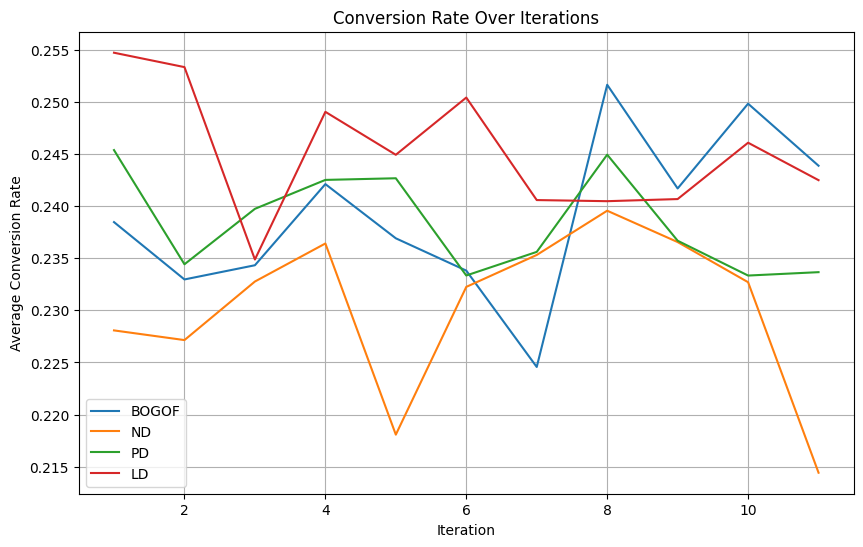

In [313]:
import matplotlib.pyplot as plt
#Plot conversion rate trends over iterations
import matplotlib.pyplot as plt

# Create a new figure for the plot
plt.figure(figsize=(10, 6))

# Loop through each treatment (BOGOF, ND, PD, LD)
for i in range(num_variants):
    # Collect the conversion rate history for this treatment
    conversion_rates = []
    for round_result in conversion_history:
        conversion_rates.append(round_result[i])

    # Plot the line for this treatment
    plt.plot(range(1, len(conversion_rates) + 1), conversion_rates, label=treatments[i])

# Add chart title and labels
plt.title("Conversion Rate Over Iterations")
plt.xlabel("Iteration")
plt.ylabel("Average Conversion Rate")
plt.legend()
plt.grid(True)

# Show the plot
plt.show()


In [314]:
from tabulate import tabulate

# Create DataFrame
alloc_df = pd.DataFrame(allocation_history, columns=treatments)
alloc_df['Iteration'] = range(1, len(allocation_history) + 1)
alloc_df = alloc_df[['Iteration'] + treatments]

# Print clean table without index
print("\n=== Sample Allocation Table ===")
print(tabulate(alloc_df.values, headers=alloc_df.columns, tablefmt='grid'))



=== Sample Allocation Table ===
+-------------+---------+------+------+------+
|   Iteration |   BOGOF |   ND |   PD |   LD |
+=============+=========+======+======+======+
|           1 |      25 |   25 |   25 |   25 |
+-------------+---------+------+------+------+
|           2 |      23 |   20 |   24 |   33 |
+-------------+---------+------+------+------+
|           3 |      21 |   16 |   32 |   31 |
+-------------+---------+------+------+------+
|           4 |      19 |   13 |   30 |   38 |
+-------------+---------+------+------+------+
|           5 |      17 |   10 |   28 |   45 |
+-------------+---------+------+------+------+
|           6 |      16 |    8 |   25 |   51 |
+-------------+---------+------+------+------+
|           7 |      13 |    7 |   24 |   56 |
+-------------+---------+------+------+------+
|           8 |      21 |    6 |   23 |   50 |
+-------------+---------+------+------+------+
|           9 |      26 |    5 |   21 |   48 |
+-------------+---------+--

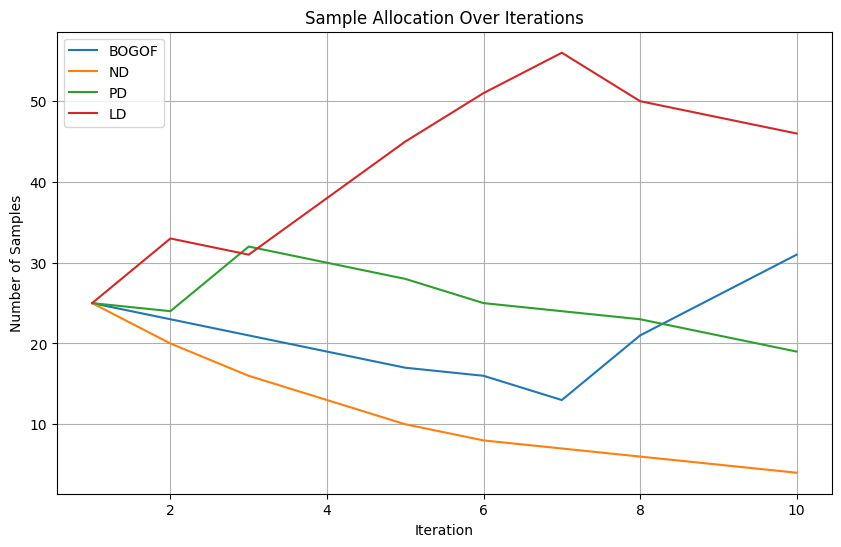

In [315]:
import matplotlib.pyplot as plt

# Step 6: Plot sample allocation changes over iterations
plt.figure(figsize=(10, 6))

# Loop through each treatment
for i in range(num_variants):
    # Get the allocation history for this treatment
    sample_counts = []
    for round_alloc in allocation_history:
        sample_counts.append(round_alloc[i])

    # Plot the line
    plt.plot(range(1, len(sample_counts) + 1), sample_counts, label=treatments[i])

# Add chart title and labels
plt.title("Sample Allocation Over Iterations")
plt.xlabel("Iteration")
plt.ylabel("Number of Samples")
plt.legend()
plt.grid(True)

# Show the chart
plt.show()


#**1.3: Thompson Sampling - Bayesian Method**


<mark>**Note: This method closely follows the format given to us in the additional resources on Quercus.**

Sample data:<br>
Each row is a participant. There are 292 participant, each of them have 4 possible treatment types. This sample size is based on the value computed once we added 4 variants/categorical variables <br>

We created a table format so that it is easier to iterate and create graphs: <br>
1 means that the converison rate is above 0.3 <br>
0 means that converison rate is below 0.3

In [316]:
# Step 1: Extract the relevant columns
df_subset = df_parallel[['Participant ID', 'DiscountType', 'Conversion_Rate']].copy()

# Step 2: Binarize the Conversion Rate to get High_Conversion (0 or 1)
df_subset['High_Conversion'] = (df_subset['Conversion_Rate'] > 0.3).astype(int)

# Map DiscountType to short labels (treatment types)
discount_mapping = {
    'Buy One Get One Free': 'BOGOF',
    'No Discount': 'ND',
    'Percentage Discount': 'PD',
    'Loyalty Discount': 'LD'
}

df_subset['Treatment_Label'] = df_subset['DiscountType'].map(discount_mapping)

# Create a DataFrame of zeros
df_wide = pd.DataFrame(0, index=df_subset['Participant ID'].unique(), columns=['BOGOF', 'ND', 'PD', 'LD'])

# Iterate through the rows of df_subset and update the appropriate treatment column
for index, row in df_subset.iterrows():
    participant_id = row['Participant ID']
    treatment_label = row['Treatment_Label']
    high_conversion = row['High_Conversion']

    # Updating the corresponding treatment column with the High_Conversion value
    df_wide.loc[participant_id, treatment_label] = high_conversion

# Resetting the index
df_wide = df_wide.reset_index(drop=True)

# Displaying the result
df_wide.head(5)

,BOGOF,ND,PD,LD
0,0,0,0,0
1,0,1,0,0
2,0,0,0,0
3,0,0,0,0
4,1,0,0,0


This is roughly the counts of the four treatments from table aboce that have a conversion rate above 0.3. Please note that the conversion rate was arbitrarily chosen, since 0.3 is a reasonable threshold.

In [317]:
treatment_counts = df_wide.sum()
print(treatment_counts)

BOGOF    54
ND       57
PD       54
LD       55
dtype: int64


Bar chart of the distribution above

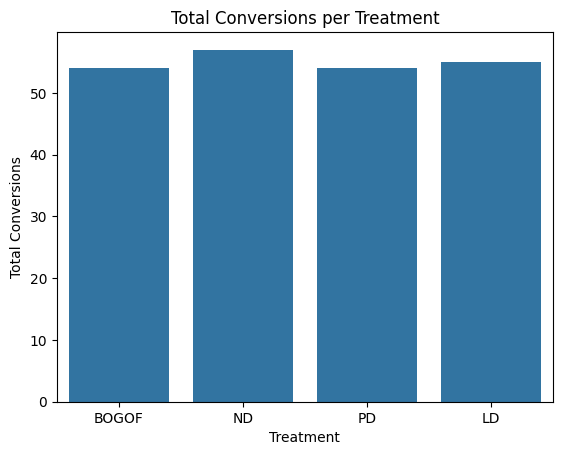

In [318]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a bar plot of the conversion counts for each treatment
conversion_counts = df_wide.sum()

# Plot
sns.barplot(x=conversion_counts.index, y=conversion_counts.values)
plt.xlabel('Treatment')
plt.ylabel('Total Conversions')
plt.title('Total Conversions per Treatment')
plt.show()

Thompson Sampling below makes use of beta distribution for each arm, and the treatment is selected based on the beta distribution sampling. Since our sample size is 292, we plot a graph at increments of 50 samples. This means that the final plot will be at 250 samples.

In [319]:
x = np.linspace(0, 1.0, 200)

N = df_wide.shape[0]

d = df_wide.shape[1]

print(df_wide.sum())

BOGOF    54
ND       57
PD       54
LD       55
dtype: int64


In [320]:
from tqdm import tqdm
import random

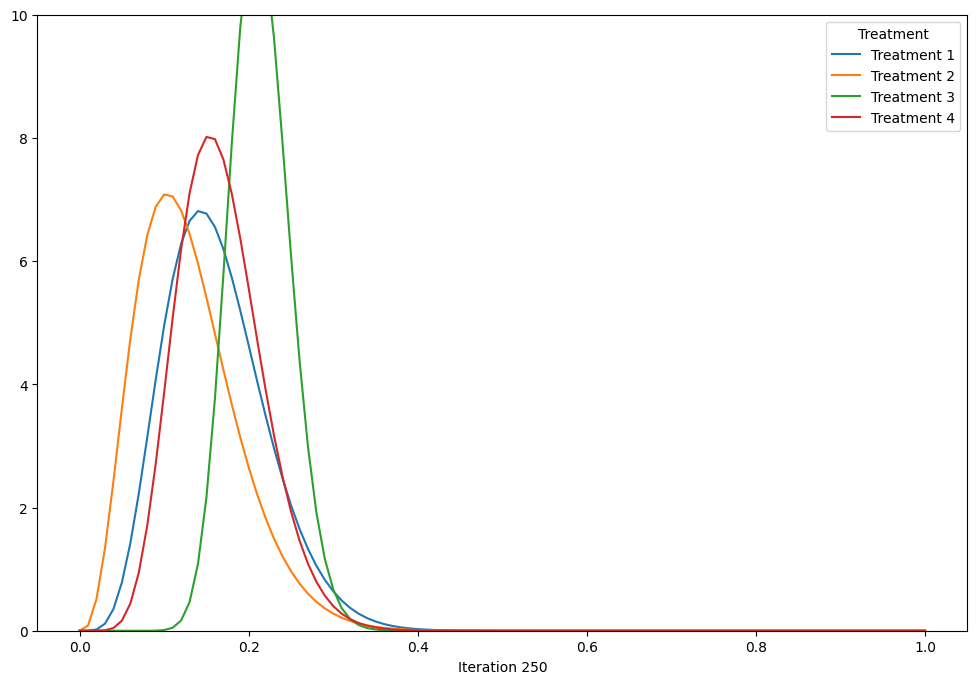

100%|██████████| 292/292 [00:04<00:00, 70.62it/s]


Sample Size Reallocation Table:
  Treatment  Number of Times Selected
0     BOGOF                        43
3        LD                        64
1        ND                        31
2        PD                       154

The winning treatment is PD
Total reward: 50


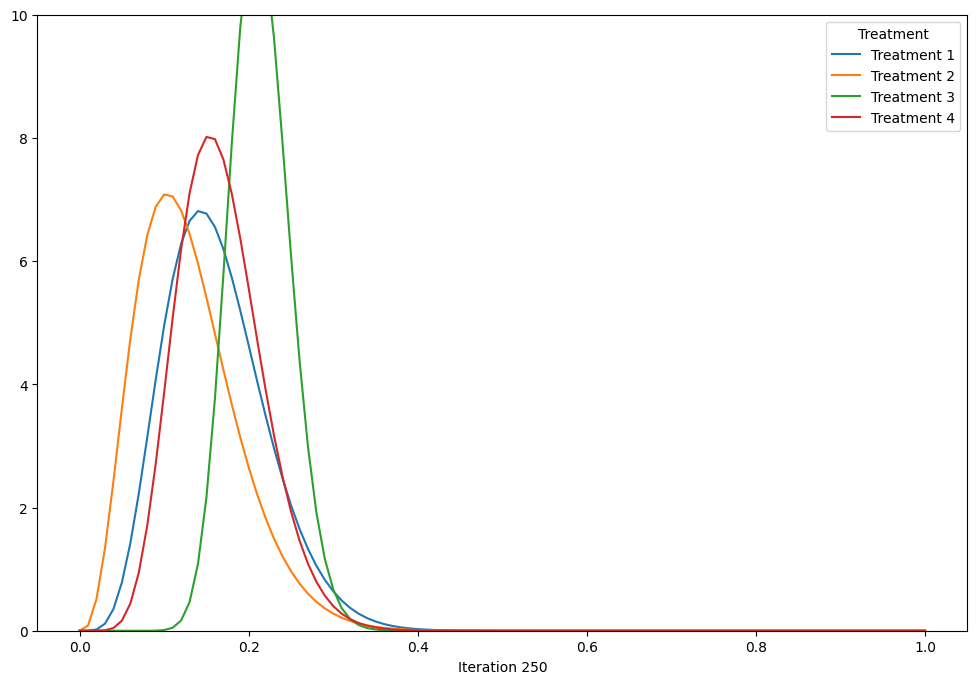

In [321]:
from scipy.stats import beta
import IPython

# Derive treatment names from the column names of df_wide
treatment_names = df_wide.columns.tolist()

x = np.linspace(0, 1.0, 200)

N = df_wide.shape[0]

d = df_wide.shape[1]

PLOTTING_AT_EVERY_N = 50

SHOW_PLOT = True

conversion_rate = []
number_of_wins = [0] * d
number_of_losses = [0] * d
total_reward = 0
# for n in range(0, N):
fig, ax = plt.subplots(figsize=(12, 8))

# Initialize a list to track the number of times each treatment was selected
treatment_selection_count = [0] * d

# Simulate the bandit process
for n in tqdm(range(0, N)):
  if SHOW_PLOT:
    if n % PLOTTING_AT_EVERY_N == 0:
      # Clear the current plot
      ax.cla()
      print(f"Iteration: {n}")
      # Plot the current Beta distributions for each arm
      for i in range(0, d):
        # Range from 0 to 1 with step 0.01
        x = [i / 100.0 for i in range(0, 101)]
        sns.lineplot(x=x, y=beta.pdf(x, number_of_wins[i] + 1, number_of_losses[i] + 1), label=f"Treatment {i + 1}", ax=ax)

        ax.set(ylim=(0, 10))
        ax.set(xlabel=f"Iteration {n}")
        ax.legend(title="Treatment")
        IPython.display.clear_output(wait=True)
        IPython.display.display(plt.gcf())
        # time.sleep(0.01)

    # Select the treatment using Beta distribution sampling
    treatment = 0
    max_random = 0
    for i in range(0, d):
        random_beta = random.betavariate(number_of_wins[i] + 1, number_of_losses[i] + 1)
        if random_beta > max_random:
            max_random = random_beta
            treatment = i

    # Record the treatment selected
    reward = df_wide.iloc[n, treatment]
    # Increment the selection count
    treatment_selection_count[treatment] += 1

    # Update the number of wins and losses based on the reward (1 = success, 0 = failure)
    if reward == 1:
        number_of_wins[treatment] += 1
    else:
        number_of_losses[treatment] += 1

    # Update the total reward
    total_reward += reward
    conversion_rate.append(treatment)

# Condition 4: Table showing how often each treatment was selected
selection_table = pd.Series(treatment_selection_count, index=treatment_names).reset_index()
selection_table.columns = ['Treatment', 'Number of Times Selected']
selection_table = selection_table.sort_values(by='Treatment')
print("\nSample Size Reallocation Table:")
print(selection_table)

# Condition 5: Determine the winning treatment (the one with the most wins)
winning_treatment = max(range(d), key=lambda i: number_of_wins[i])
print(f"\nThe winning treatment is {treatment_names[winning_treatment]}")

# Final results
print(f"Total reward: {total_reward}")

Plotting a bar chart of the winning treatment as per our algorithm above.

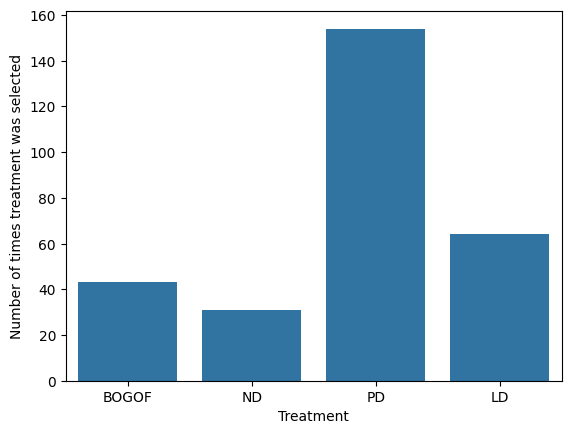

In [322]:
# Plot the number of times each treatment was selected
dftemp = pd.DataFrame(pd.Series(conversion_rate).value_counts()).reset_index()
dftemp.columns = ['Treatment', 'Count']

# Plot the results
ax = sns.barplot(data=dftemp, x='Treatment', y='Count')
ax.set(xlabel='Treatment', ylabel='Number of times treatment was selected')
# 4 treatments
ax.set_xticks(range(0, 4))
ax.set_xticklabels(['BOGOF', 'ND', 'PD', 'LD'])
plt.show()

In [323]:
# Count how often each treatment was selected based on conversion rate
selected = pd.Series(conversion_rate).value_counts()

# Adjust the index to match the treatment names derived from df_wide columns
selected.index = selected.index.map(lambda i: treatment_names[i])

# Reset the index to create a proper DataFrame and sort by Treatment name
selected = selected.reset_index().sort_values(by=['index'])

# Rename the columns to be more descriptive
selected.rename({'index': 'Treatment'}, axis=1, inplace=True)
selected.rename({0: 'Number of Times Conversion Rate > 0.3'}, axis=1, inplace=True)

# Display the table
print(selected)

  Treatment  count
2     BOGOF     43
1        LD     64
3        ND     31
0        PD    154


In [324]:
# Printing the total reward
print('Total reward is:', total_reward)

# Percentage of total reward compared to maximum possible reward
percentage_reward = total_reward * 100 / max(df_wide.sum())

print(f"Percentage of total reward compared to max: {percentage_reward.round(2)}")

# Remaining percentage of reward
remaining_percentage = 100 - percentage_reward
print(f"Remaining percentage of reward: {remaining_percentage.round(2)}")

Total reward is: 50
Percentage of total reward compared to max: 87.72
Remaining percentage of reward: 12.28


# **2. Causal Inference Model**

In [325]:
# Setting the seed for reproducibility
np.random.seed(42)

# Defining the group combinations based on above parallel design
parallel_conditions = [
    ('Buy One Get One Free'),  # Group 1
    ('No Discount'),  # Group 2
    ('Percentage Discount'), # Group 3
    ('Loyalty Discount')  # Group 4
]
# Initializing the list to store assigned treatment levels
treatment_assignments = []

num_groups_p = len(parallel_conditions)

# Randomly assign participants to groups by shuffling the IDs
np.random.shuffle(df['Participant ID'].values)

# Assigning participants evenly to parallel design groups using a loop
for i in range(len(df)):
    # Cycling through the 2 groups in the given order
    group_index = i % num_groups_p
    # Getting the corresponding treatment levels
    treatment = parallel_conditions[group_index]
    # Appending the assigned discount condition
    treatment_assignments.append(treatment)

# Adding the factor assignments to the DataFrame
df['DiscountType'] = treatment_assignments

# Now we will generate the dependent variables for this experiment
n_samples = len(df)

# Initializing activity data with zeros as placeholders
frequency_of_visits = np.zeros(n_samples)
frequency_of_made_purchase = np.zeros(n_samples)

# Define mean and standard deviation values for visit frequency based on treatment type
# Higher expected visits for promotional offer
visit_mean_treatment, visit_std_treatment = 30, 10
# Lower expected visits without discount
visit_mean_control, visit_std_control = 12, 5
# Higher visits for loyalty members
visit_mean_loyalty, visit_std_loyalty = 35, 8
# Standard deviation as a fraction of mean visits to account for variability
purchase_std_factor = 0.5

# Looping through each of the rows
for i in range(n_samples):
  # Holds the treatment type ('Buy One Get One Free' or 'No Discount') for the current participant
  treatments = treatment_assignments[i]

  if treatments == 'Buy One Get One Free':
    # Generate frequency of visits from normal distribution, with non-negative values
    frequency_of_visits[i] = max(0, int(np.random.normal(visit_mean_treatment, visit_std_treatment)))
  elif treatments == 'Percentage Discount':
    # Generate frequency of made purchase from normal distribution, with non-negative values greater than 5
    frequency_of_made_purchase[i] = max(5, int(np.random.normal(10, 3)))
    # Generate frequency of visits from normal distribution, with non-negative values greater than or equal to the # of visits
    frequency_of_visits[i] = max(frequency_of_made_purchase[i], int(np.random.normal(25, 7)))
  elif treatments == 'Loyalty Discount':
    # Generate frequency of visits from normal distribution, with non-negative values greater than or equal to 25 visits
    frequency_of_visits[i] = max(25, int(np.random.normal(visit_mean_loyalty, visit_std_loyalty)))
  else:
    # Generate frequency of visits from normal distribution, with non-negative values
    frequency_of_visits[i] = max(0, int(np.random.normal(visit_mean_control, visit_std_control)))

  # Generate purchase frequency based on visits, ensuring it does not exceed visits
  # Assuming 50% conversion rate on average
  purchase_mean = frequency_of_visits[i] * 0.5
  # Define variability in purchases
  purchase_std = purchase_mean * purchase_std_factor
  # Generate the number of purchases, ensuring it is within valid bounds (0 to total visits)
  frequency_of_made_purchase[i] = max(0, min(frequency_of_visits[i], int(np.random.normal(purchase_mean, purchase_std))))

# Calculating conversion rate: purchases made to visits but accounting for zero values
conversion_rate = np.divide(frequency_of_made_purchase, frequency_of_visits, where=frequency_of_visits > 0)
# Replacing any strange values with 0 (i.e. NaN, negative & positive infinity)
conversion_rate = np.nan_to_num(conversion_rate, nan=0, posinf=0, neginf=0)
conversion_rate = np.round(conversion_rate, 5)

# Rounding the values for the dependent variables
frequency_of_visits = np.round(frequency_of_visits, 2)
frequency_of_made_purchase = np.round(frequency_of_made_purchase, 2)

# Creating activity DataFrame
activity_data = pd.DataFrame({
    "Participant ID": df["Participant ID"],
    "Conversion_Rate": conversion_rate
})

# Merging the membership status and activity data together
df = df.merge(activity_data, on="Participant ID")

# Count the number of participants in each treatment group
treatment_counts = df['DiscountType'].value_counts()

# Print out the counts to make sure they are evenly distributed
print(treatment_counts)
print("\n")

# Show the demographic data for the selected participants
df.head()


DiscountType
Buy One Get One Free    2500
No Discount             2500
Percentage Discount     2500
Loyalty Discount        2500
Name: count, dtype: int64




,Participant ID,Age,Gender,Location,Income,Frequency in the Past,Historical Visits,Device Type,Preferred Payment Method,Membership Status,Exposure to Social Media Promotion,Membership_Status,DiscountType,Conversion_Rate
0,6253,64,Female,Victoria,124299,not frequent,10,Desktop,Bank Transfers,Basic,Yes,Gold,Buy One Get One Free,0.69565
1,4685,61,Female,Montreal,29708,frequent,62,Tablet,Buy Now Pay Later,Silver,Yes,Platinum,No Discount,0.08000
2,1732,66,Male,Victoria,98311,frequent,68,Tablet,Credit Card,Gold,Yes,Basic,Percentage Discount,0.77778
3,4743,32,Non-Binary,Kelowna,199538,frequent,55,Mobile,PayPal,Platinum,No,Gold,Loyalty Discount,0.54545
4,4522,32,Female,Hamilton,174238,not frequent,6,Tablet,Digital Wallet,Gold,Yes,Gold,Buy One Get One Free,0.11111


In [326]:
# Filter the DataFrame for only "Buy One Get One Free" and "No Discount" groups
filtered_df = df.copy()[df['DiscountType'].isin(['Buy One Get One Free', 'No Discount'])]

filtered_df.head()

,Participant ID,Age,Gender,Location,Income,Frequency in the Past,Historical Visits,Device Type,Preferred Payment Method,Membership Status,Exposure to Social Media Promotion,Membership_Status,DiscountType,Conversion_Rate
0,6253,64,Female,Victoria,124299,not frequent,10,Desktop,Bank Transfers,Basic,Yes,Gold,Buy One Get One Free,0.69565
1,4685,61,Female,Montreal,29708,frequent,62,Tablet,Buy Now Pay Later,Silver,Yes,Platinum,No Discount,0.08000
4,4522,32,Female,Hamilton,174238,not frequent,6,Tablet,Digital Wallet,Gold,Yes,Gold,Buy One Get One Free,0.11111
5,6341,38,Female,Ottawa,140036,not frequent,50,Mobile,Digital Wallet,Basic,No,Platinum,No Discount,0.62500
8,6364,28,Female,Winnipeg,48483,not frequent,41,Mobile,Bank Transfers,Gold,Yes,Gold,Buy One Get One Free,0.34483


In [327]:
# Use .loc[] to assign 1 for 'Buy One Get One Free' and 0 for 'No Discount'
filtered_df.loc[filtered_df['DiscountType'] == 'Buy One Get One Free', 'DiscountType'] = 1
filtered_df.loc[filtered_df['DiscountType'] == 'No Discount', 'DiscountType'] = 0

filtered_df = filtered_df[filtered_df['DiscountType'].isin([0, 1])].copy()
filtered_df['DiscountType'] = filtered_df['DiscountType'].astype(int)


filtered_df.head()

,Participant ID,Age,Gender,Location,Income,Frequency in the Past,Historical Visits,Device Type,Preferred Payment Method,Membership Status,Exposure to Social Media Promotion,Membership_Status,DiscountType,Conversion_Rate
0,6253,64,Female,Victoria,124299,not frequent,10,Desktop,Bank Transfers,Basic,Yes,Gold,1,0.69565
1,4685,61,Female,Montreal,29708,frequent,62,Tablet,Buy Now Pay Later,Silver,Yes,Platinum,0,0.08000
4,4522,32,Female,Hamilton,174238,not frequent,6,Tablet,Digital Wallet,Gold,Yes,Gold,1,0.11111
5,6341,38,Female,Ottawa,140036,not frequent,50,Mobile,Digital Wallet,Basic,No,Platinum,0,0.62500
8,6364,28,Female,Winnipeg,48483,not frequent,41,Mobile,Bank Transfers,Gold,Yes,Gold,1,0.34483


In [328]:
#define a new df for alternative casual inference model
alternate_df = filtered_df.copy()

alternate_df.head()

,Participant ID,Age,Gender,Location,Income,Frequency in the Past,Historical Visits,Device Type,Preferred Payment Method,Membership Status,Exposure to Social Media Promotion,Membership_Status,DiscountType,Conversion_Rate
0,6253,64,Female,Victoria,124299,not frequent,10,Desktop,Bank Transfers,Basic,Yes,Gold,1,0.69565
1,4685,61,Female,Montreal,29708,frequent,62,Tablet,Buy Now Pay Later,Silver,Yes,Platinum,0,0.08000
4,4522,32,Female,Hamilton,174238,not frequent,6,Tablet,Digital Wallet,Gold,Yes,Gold,1,0.11111
5,6341,38,Female,Ottawa,140036,not frequent,50,Mobile,Digital Wallet,Basic,No,Platinum,0,0.62500
8,6364,28,Female,Winnipeg,48483,not frequent,41,Mobile,Bank Transfers,Gold,Yes,Gold,1,0.34483


In [329]:
# Replace -inf with NaN
filtered_df['Conversion_Rate'] = filtered_df['Conversion_Rate'].replace([-np.inf], np.nan)

# Replace inf with NaN
filtered_df['Conversion_Rate'] = filtered_df['Conversion_Rate'].replace([np.inf], np.nan)

# Option 1: Drop NaN values
filtered_df.dropna(subset=['Conversion_Rate'], inplace=True)

# Calculate the mean of 'Conversion_Rate' excluding zeros
mean_conversion_rate = filtered_df['Conversion_Rate'][filtered_df['Conversion_Rate'] != 0].mean()

# Replace zeros with the calculated mean
filtered_df['Conversion_Rate'] = filtered_df['Conversion_Rate'].replace(0, mean_conversion_rate)

In [330]:
print(filtered_df['DiscountType'].unique())

[1 0]


In [331]:
print(filtered_df[['DiscountType', 'Conversion_Rate']].describe())


       DiscountType  Conversion_Rate
count    5000.00000      5000.000000
mean        0.50000         0.487273
std         0.50005         0.216387
min         0.00000         0.023810
25%         0.00000         0.333330
50%         0.50000         0.487273
75%         1.00000         0.631580
max         1.00000         1.000000


In [332]:
print(filtered_df[['DiscountType', 'Conversion_Rate']].isin([np.inf, -np.inf]).sum())

DiscountType       0
Conversion_Rate    0
dtype: int64


In [333]:
print(filtered_df.isnull().sum()) #make sure there is no missing values

Participant ID                        0
Age                                   0
Gender                                0
Location                              0
Income                                0
Frequency in the Past                 0
Historical Visits                     0
Device Type                           0
Preferred Payment Method              0
Membership Status                     0
Exposure to Social Media Promotion    0
Membership_Status                     0
DiscountType                          0
Conversion_Rate                       0
dtype: int64


In [334]:
print(alternate_df[['DiscountType', 'Conversion_Rate']].describe())

       DiscountType  Conversion_Rate
count    5000.00000      5000.000000
mean        0.50000         0.458231
std         0.50005         0.245221
min         0.00000         0.000000
25%         0.00000         0.285710
50%         0.50000         0.458330
75%         1.00000         0.631580
max         1.00000         1.000000


In [335]:
print(alternate_df[['DiscountType', 'Conversion_Rate']].isin([np.inf, -np.inf]).sum())

DiscountType       0
Conversion_Rate    0
dtype: int64


In [336]:
# Replace -inf with NaN
alternate_df['Conversion_Rate'] = alternate_df['Conversion_Rate'].replace([-np.inf], np.nan)

# Option 1: Drop NaN values
alternate_df.dropna(subset=['Conversion_Rate'], inplace=True)




In [337]:
print(alternate_df.isnull().sum()) #make sure there is no missing values

Participant ID                        0
Age                                   0
Gender                                0
Location                              0
Income                                0
Frequency in the Past                 0
Historical Visits                     0
Device Type                           0
Preferred Payment Method              0
Membership Status                     0
Exposure to Social Media Promotion    0
Membership_Status                     0
DiscountType                          0
Conversion_Rate                       0
dtype: int64


In [338]:
# if not installed
!pip install dowhy
!pip install graphviz

**Causal Inference Using DoWhy**

1.  Specify the causal realationships among the variables and initialize the causal model based on the specific graph.

2.   The graph reflects assumptions such as previous shopping frequency, membership status, and the type of device influencing both the type of discount received and directly affecting the conversion rate.

3.   Plot DAG(Directed Acyclic Graph)







ERROR:dowhy.causal_graph:Error: Pygraphviz cannot be loaded. No module named 'pygraphviz'
Trying pydot ...


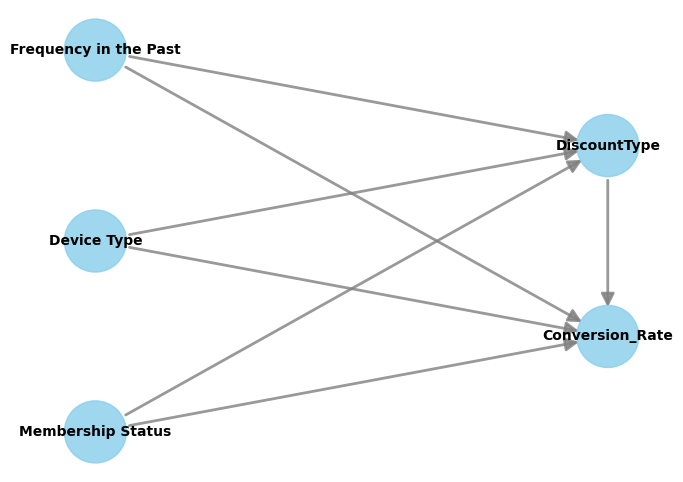

In [339]:
import dowhy
import graphviz
from dowhy import CausalModel

# Define the causal graph using DoWhy syntax
causal_graph = """
digraph {
    "Frequency in the Past" -> DiscountType;
    "Membership Status" -> DiscountType;
    "Device Type" -> DiscountType;
    DiscountType -> Conversion_Rate;
    "Frequency in the Past" -> Conversion_Rate;
    "Membership Status" -> Conversion_Rate;
    "Device Type" -> Conversion_Rate;
}
"""

# Create a causal model from the graph
model = CausalModel(
    data=filtered_df,
    graph=causal_graph,
    treatment=["DiscountType"],
    outcome=["Conversion_Rate"]
)

# Visualize the causal graph
model.view_model()


Perform a linear regression analysis to assess the effect of the treatment (discount type) on the outcome (conversion rate)

In [340]:
# Run a linear regression of column y on v0 in df
import statsmodels.api as sm

X = filtered_df['DiscountType'].astype(int)
y = filtered_df['Conversion_Rate'].astype(float)

X = sm.add_constant(X)

ols = sm.OLS(y, X).fit()

# Display a more parsimonious results summary
print(ols.summary().tables[1])

                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.4811      0.004    111.200      0.000       0.473       0.490
DiscountType     0.0124      0.006      2.020      0.043       0.000       0.024


**Determine estimand**
Focus on controlling for the specified confounders (Device Type, Frequency in the Past, Membership Status) when estimating the effect of DiscountType on Conversion_Rate.

In [341]:
identified_estimand = model.identify_effect(proceed_when_unidentifiable=True) # determine estimand
print(identified_estimand)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
       d                                                                               
───────────────(E[Conversion_Rate|Membership Status,Device Type,Frequency in the Past])
d[DiscountType]                                                                        
Estimand assumption 1, Unconfoundedness: If U→{DiscountType} and U→Conversion_Rate then P(Conversion_Rate|DiscountType,Membership Status,Device Type,Frequency in the Past,U) = P(Conversion_Rate|DiscountType,Membership Status,Device Type,Frequency in the Past)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!



**Perform a causal effect estimation using the method of inverse probability weighting (IPW)**
Balance the distribution of confounders across treatment groups.
If some groups are more likely to receive the treatment due to their characteristics, IPW corrects for this.

In [342]:
# Estimate the causal effect using inverse probability weighting
estimate = model.estimate_effect(identified_estimand,
                                 method_name="backdoor.propensity_score_weighting")
print(estimate)

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
       d                                                                               
───────────────(E[Conversion_Rate|Membership Status,Device Type,Frequency in the Past])
d[DiscountType]                                                                        
Estimand assumption 1, Unconfoundedness: If U→{DiscountType} and U→Conversion_Rate then P(Conversion_Rate|DiscountType,Membership Status,Device Type,Frequency in the Past,U) = P(Conversion_Rate|DiscountType,Membership Status,Device Type,Frequency in the Past)

## Realized estimand
b: Conversion_Rate~DiscountType+Membership Status+Device Type+Frequency in the Past
Target units: ate

## Estimate
Mean value: 0.012432046269730546



**Propensity Score Matching**
Propensity Score: The probability of receiving a particular treatment given pre-treatment characteristics.In this case, it relates to receiving different types of discounts based on variables such as Device Type, Frequency in the Past, and Membership Status.
Addressing Cofounding: It ensures that any observed effect is more likely due to the treatment rather than differences in baseline characteristics.



In [343]:
causal_estimate_match = model.estimate_effect(identified_estimand,
                                             method_name = "backdoor.propensity_score_matching"
                                             )
print(causal_estimate_match)

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
       d                                                                               
───────────────(E[Conversion_Rate|Membership Status,Device Type,Frequency in the Past])
d[DiscountType]                                                                        
Estimand assumption 1, Unconfoundedness: If U→{DiscountType} and U→Conversion_Rate then P(Conversion_Rate|DiscountType,Membership Status,Device Type,Frequency in the Past,U) = P(Conversion_Rate|DiscountType,Membership Status,Device Type,Frequency in the Past)

## Realized estimand
b: Conversion_Rate~DiscountType+Membership Status+Device Type+Frequency in the Past
Target units: ate

## Estimate
Mean value: 0.11302855834368354



**Refute Estimate Method**
It's a sensitivity analysis for validating the strength and reliability of causal inferences.

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/numpy/_core/fromnumeric.py:3800: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)
/usr/local/lib/python3.11/dist-packages/dowhy/causal_refuters/add_unobserved_common_cause.py:321: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  std_dev_y = np.std(y)[0]


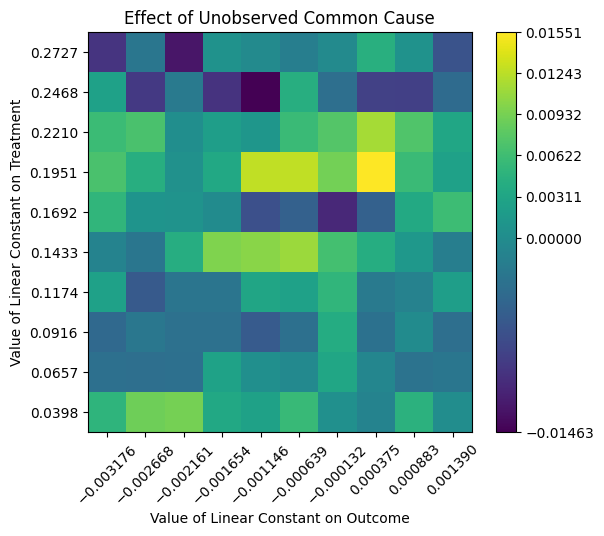

In [344]:
# Check sensitivity of obtained estimate to unobserved confounders
refute_results = model.refute_estimate(identified_estimand, estimate,
                                       method_name="add_unobserved_common_cause")

#**2.1 Alternative Causal Inference Model**

1.  Specify the causal realationships among the variables and provide the alternative causal model based on the updated graph.

2. Income is added as a new variable for alternative casual inference model.

3.   Plot DAG(Directed Acyclic Graph)

ERROR:dowhy.causal_graph:Error: Pygraphviz cannot be loaded. No module named 'pygraphviz'
Trying pydot ...


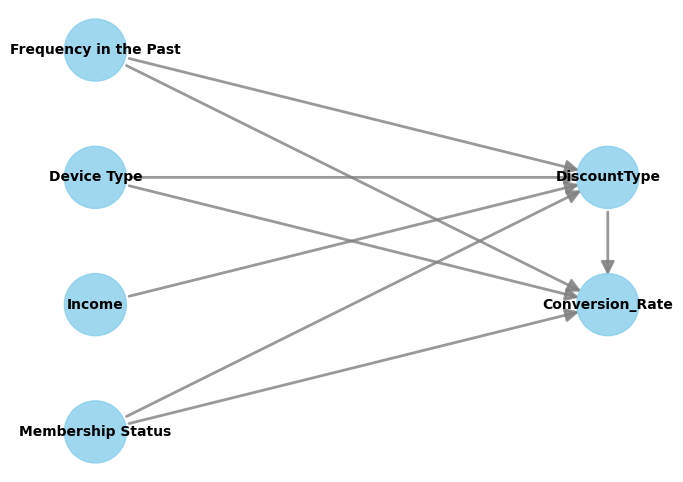

In [345]:
import dowhy
import graphviz
from dowhy import CausalModel

# Define the causal graph using DoWhy syntax
causal_graph_al = """
digraph {
    "Frequency in the Past" -> DiscountType;
    "Membership Status" -> DiscountType;
    "Device Type" -> DiscountType;
    Income -> DiscountType;
    DiscountType -> Conversion_Rate;
    "Frequency in the Past" -> Conversion_Rate;
    "Membership Status" -> Conversion_Rate;
    "Device Type" -> Conversion_Rate;
}
"""

# Create a causal model from the graph
model_al = CausalModel(
    data=alternate_df,
    graph=causal_graph_al,
    treatment=["DiscountType"],
    outcome=["Conversion_Rate"]
)

# Visualize the causal graph
model_al.view_model()


Perform a linear regression analysis to assess the effect of the treatment (discount type) on the outcome (conversion rate)

In [346]:
# Run a linear regression of column y on v0 in df
import statsmodels.api as sm

X = alternate_df['DiscountType'].astype(int)
y = alternate_df['Conversion_Rate'].astype(float)

X = sm.add_constant(X)

ols = sm.OLS(y, X).fit()

# Display a more parsimonious results summary
print(ols.summary().tables[1])

                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.4386      0.005     89.709      0.000       0.429       0.448
DiscountType     0.0393      0.007      5.677      0.000       0.026       0.053


**Determine estimand**
Focus on controlling for the specified confounders (Device Type, Frequency in the Past, Membership Status, Income) when estimating the effect of DiscountType on Conversion_Rate.

In [347]:
identified_estimand_al = model_al.identify_effect(proceed_when_unidentifiable=True) # determine estimand
print(identified_estimand_al)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
       d                                                                               
───────────────(E[Conversion_Rate|Membership Status,Device Type,Frequency in the Past])
d[DiscountType]                                                                        
Estimand assumption 1, Unconfoundedness: If U→{DiscountType} and U→Conversion_Rate then P(Conversion_Rate|DiscountType,Membership Status,Device Type,Frequency in the Past,U) = P(Conversion_Rate|DiscountType,Membership Status,Device Type,Frequency in the Past)

### Estimand : 2
Estimand name: iv
Estimand expression:
 ⎡                                                      -1⎤
 ⎢    d                      ⎛    d                    ⎞  ⎥
E⎢─────────(Conversion_Rate)⋅⎜─────────([DiscountType])⎟  ⎥
 ⎣d[Income]                  ⎝d[Income]                ⎠  ⎦
Estimand assumption 1, As-if-random: If U→→Conversion_Rate then ¬(U →→

**Perform a causal effect estimation using the method of inverse probability weighting (IPW)**
Balance the distribution of confounders across treatment groups.
If some groups are more likely to receive the treatment due to their characteristics, IPW corrects for this.

In [348]:
# Estimate the causal effect using inverse probability weighting
estimate_al = model_al.estimate_effect(identified_estimand_al,
                                 method_name="backdoor.propensity_score_weighting")
print(estimate_al)

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
       d                                                                               
───────────────(E[Conversion_Rate|Membership Status,Device Type,Frequency in the Past])
d[DiscountType]                                                                        
Estimand assumption 1, Unconfoundedness: If U→{DiscountType} and U→Conversion_Rate then P(Conversion_Rate|DiscountType,Membership Status,Device Type,Frequency in the Past,U) = P(Conversion_Rate|DiscountType,Membership Status,Device Type,Frequency in the Past)

## Realized estimand
b: Conversion_Rate~DiscountType+Membership Status+Device Type+Frequency in the Past
Target units: ate

## Estimate
Mean value: 0.03934365789542149



**Propensity Score Matching**
Propensity Score: The probability of receiving a particular treatment given pre-treatment characteristics.In this case, it relates to receiving different types of discounts based on variables such as Device Type, Frequency in the Past, Membership Status and Income.
Addressing Cofounding: It ensures that any observed effect is more likely due to the treatment rather than differences in baseline characteristics.



In [349]:
causal_estimate_match_al = model_al.estimate_effect(identified_estimand_al,
                                             method_name = "backdoor.propensity_score_matching"
                                             )
print(causal_estimate_match_al)

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
       d                                                                               
───────────────(E[Conversion_Rate|Membership Status,Device Type,Frequency in the Past])
d[DiscountType]                                                                        
Estimand assumption 1, Unconfoundedness: If U→{DiscountType} and U→Conversion_Rate then P(Conversion_Rate|DiscountType,Membership Status,Device Type,Frequency in the Past,U) = P(Conversion_Rate|DiscountType,Membership Status,Device Type,Frequency in the Past)

## Realized estimand
b: Conversion_Rate~DiscountType+Membership Status+Device Type+Frequency in the Past
Target units: ate

## Estimate
Mean value: 0.146358014



**Refute Estimate Method**
It's a sensitivity analysis for validating the strength and reliability of causal inferences.

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/numpy/_core/fromnumeric.py:3800: FutureWarning: The behavior of DataFrame.std with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return std(axis=axis, dtype=dtype, out=out, ddof=ddof, **kwargs)
/usr/local/lib/python3.11/dist-packages/dowhy/causal_refuters/add_unobserved_common_cause.py:321: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  std_dev_y = np.std(y)[0]


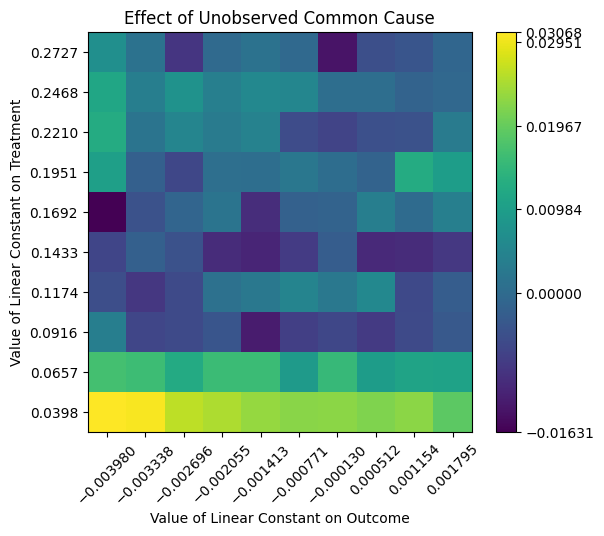

In [350]:
# Check sensitivity of obtained estimate to unobserved confounders
refute_results_al = model_al.refute_estimate(identified_estimand_al, estimate_al,
                                       method_name="add_unobserved_common_cause")

In [351]:
#estimate and print augmented/alternative model.
iv_estimate_al = model_al.estimate_effect(identified_estimand_al,
                                    method_name="iv.instrumental_variable")

In [352]:
print(iv_estimate_al)

*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: iv
Estimand expression:
 ⎡                                                      -1⎤
 ⎢    d                      ⎛    d                    ⎞  ⎥
E⎢─────────(Conversion_Rate)⋅⎜─────────([DiscountType])⎟  ⎥
 ⎣d[Income]                  ⎝d[Income]                ⎠  ⎦
Estimand assumption 1, As-if-random: If U→→Conversion_Rate then ¬(U →→{Income})
Estimand assumption 2, Exclusion: If we remove {Income}→{DiscountType}, then ¬({Income}→Conversion_Rate)

## Realized estimand
Realized estimand: Wald Estimator
Realized estimand type: EstimandType.NONPARAMETRIC_ATE
Estimand expression:
 ⎡   d                    ⎤
E⎢───────(Conversion_Rate)⎥
 ⎣dIncome                 ⎦
───────────────────────────
  ⎡   d                 ⎤  
 E⎢───────(DiscountType)⎥  
  ⎣dIncome              ⎦  
Estimand assumption 1, As-if-random: If U→→Conversion_Rate then ¬(U →→{Income})
Estimand assumpt